# Predicciones para patrones de tendencia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm
import math

En este punto se muestra cómo pronosticar los valores de una serie de tiempo que exhibe una tendencia lineal a largo
plazo. El tipo de series de tiempo para las cuales el método de proyección de tendencias es aplicable, muestra un incremento o disminución constante en el tiempo

para realizar un buen pronostico, su base radica en el siguiente formula:

$$ y_{t+p}=A_{t}+B_{t}*p$$


Donde:

$A_{t}$ = Estimación del nivel actual ( Regresión Lineal Simple )

$B_{t}$ = Estimación de la pendiente o tendencia

$p$ = número de períodos hacia adelante que quieres pronosticar.


Cuando hay tendencia, no basta con saber «el valor promedio actual». También necesitas saber cuánto se mueve por período.


Para determinar que una muestra de la serie presenta un patron predominantemente tendencial. Tiene el siguiente comportamiento en sus autocorrelaciones

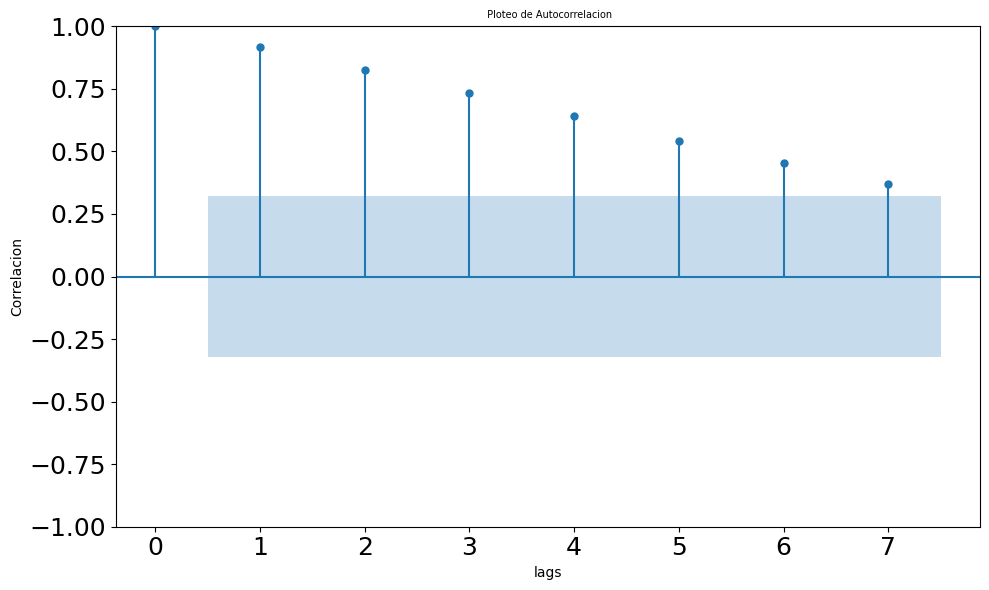

In [4]:
data = [3307,3556,3601,3721,4036,4134,4268,4578,5093,5716,6357,6769,7296,8178,8844,9251,10006,10991,12306,13101,13639,14950,17224,17946,17514,25195,27357,30020,35883,38828,40175,44282,48440,50251,53794,55972,57242]
#test de hipotesis
plt.rc("figure", figsize=(10,6))

#funcion de autocorrelacion y ploteo
plot_acf(data, lags=7,alpha=0.05,bartlett_confint=False)

plt.ylim(-1,1)
plt.xlabel('lags', fontsize=10)
plt.ylabel('Correlacion', fontsize=10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title(' Ploteo de Autocorrelacion', fontsize=7)
plt.tight_layout()
plt.show()

**Promedio Móvil Doble (PMD)**

La desventaja de el promedio móvil simple, solo logra suavizar fluctuaciones aleatorias pero no maneja bien tendencias. El promedio móvil doble aplica un promedio móvil dos veces:

-El primer promedio suaviza la serie.

-El segundo suaviza el promedio suavizado.

tomando el cuenta la formula de pronostico, las estimaciones se obtienen mediante las siguientes formulas: 
$$A_{t} = 2 * M_{t}- M´_{t} $$
$$B_{t} = \frac{2}{n-1}(M_{t}-M´_{t})$$
Donde: 
- $M_{t}$ =  Promedio móvil para el periodo t.
- $M´_{t}$ = Promedio móvil doble para el periodo 
- $n$ = Numero de periodos considerados (ventana)


Para obtener los promedios se aplica la misma tecnica que un promedio movil:
$$M_{t} = \frac{y_t + y_{t-1} + \dots + y_{t-n+1}}{n}$$

$$M´_{t} = \frac{M_t + M_{t-1} + \dots + M_{t-n+1}}{n}$$

In [21]:
# Promedio móvil simple con ventana "a"
def pmd(data, a):
    
    series = pd.Series(data)

    pmd1 = series.rolling(window=a).mean()
    pmd2 = pmd1.rolling(window=a).mean()

    at = 2 * pmd1 - pmd2
    bt = (2 / (a - 1)) * (pmd1 - pmd2)

    resultado = at + bt
    resultado_shifted = resultado.shift(1)
    #2*a dado que me desplaze el doble
    if len(series) >= 2 * a:
        futuro = pd.Series([resultado.iloc[-1]])
    else:
        futuro = pd.Series([pd.NA])

    resultado_final = pd.concat([resultado_shifted, futuro], ignore_index=True)

    return resultado_final

**Atenuacion exponencial doble de Brown**


Este método atenúa doblemente los datos, para posteriormente realizar el pronostico. Aplicando:
    $$A_{t}= \alpha*y_{t} + (1-\alpha)*A_{t-1}$$
    $$A'_{t}=\alpha * A_{t} + (1-\alpha) * A'_{t-1}$$
    
Donde:

- $A_{t}$ = Valor atenuado exponencialmente de $y_{t}$ en el periodo t.
- $A'_{t}$= Valor doblemente atenuado exponencialmente de $y_{t}$ en el periodo t.
- $a_{t}= 2A_{t}-A'_{t}$
- $b_{t}= \frac{\alpha}{1-\alpha} (A_{t}-A'_{t})$
    
Su ventaja radica en su simpleza, dado que solo se tiene que manejar un solo parametro $\alpha$. Pero al mismo tiempo no es flexible frente a cambios muy bruscos.



In [27]:
#Atenuacion exponencial doble de Brown con un parametro alfa
def aed(data, alfa):
    series = pd.Series(data)
    n = len(series)

    S1 = pd.Series(index=series.index, dtype='float64')
    S2 = pd.Series(index=series.index, dtype='float64')
    
    S1.iloc[0] = series.iloc[0]
    S2.iloc[0] = series.iloc[0]

    for t in range(1, n):
        S1.iloc[t] = alfa * series.iloc[t] + (1 - alfa) * S1.iloc[t - 1]
        S2.iloc[t] = alfa * S1.iloc[t] + (1 - alfa) * S2.iloc[t - 1]

    a_t = 2 * S1 - S2
    b_t = (alfa / (1 - alfa)) * (S1 - S2)

    resultado = a_t + b_t

    futuro = pd.Series([resultado.iloc[-1]])

    resultado_shifted = resultado.shift(1)

    resultado_final = pd.concat([resultado_shifted, futuro], ignore_index=True)

    return resultado_final

**Atenuación Exponencial Doble de Holt**

Al igual que el promedio movil doble, la atenuacion exponencial simple maneja la misma desventaja al momento de pronosticar patrones tendenciales. Es por eso se agrega un nuevo parametro $ \beta $ donde considera la pendiente y busca aplicar un suavizado ligado a la tendencia.

El pronostico se aplica mediante: 

$$ y_{t+p}=L_{t}+T_{t}*p$$

Donde: 
$$L_{t} =  αy_{t}+ (1 – α) (L_{t–1} + T_{t–1})$$

$$T_{t} = \beta (L_{t}-L_{t-1}) + (1- \beta) * T_{t-1} $$

- $ y_{t}$  = Valor de la serie de datos en el periodo t.
- $ \beta \in [0,1]$: parámetro de suavizamiento
  - Si $ \beta $ es grande → más peso a la pendiente nueva
  - Si $ \beta $ es pequeño → más peso las pendientes historicas
  
  
La aplicacion de un parametro extra ayuda al reajuste y mayor control frente al comportamiento de la serie de tiempo

In [47]:
#atenuacion exponencial doble de Holt con dos variables, alfa y beta
def aeh(data, alfa, beta):
    series = pd.Series(data)
    n = len(series)

    l = pd.Series(index=series.index, dtype='float64')
    T = pd.Series(index=series.index, dtype='float64')
    yt = pd.Series(index=series.index, dtype='float64')

    l.iloc[0] = series.iloc[0]
    T.iloc[0] = 0

    for t in range(1, n):
        l.iloc[t] = alfa * series.iloc[t] + (1 - alfa) * (l.iloc[t - 1] + T.iloc[t - 1])
        T.iloc[t] = beta * (l.iloc[t] - l.iloc[t - 1]) + (1 - beta) * T.iloc[t - 1]
        yt.iloc[t] = l.iloc[t - 1] + T.iloc[t - 1]

    yt1 = l.iloc[n - 1] + T.iloc[n - 1]
    
    resultado = pd.concat([yt, pd.Series([yt1])], ignore_index=True)

    return resultado

**Regresion lineal**

Es un modelo matemático usado para aproximar la relación de dependencia entre una variable dependiente Y, m variables independientes  $X_{i}$

$$
{ Y = a + bX + \varepsilon }
$$

- $ Y $: variable dependiente (Para estos casos, el factor dependiente es el tiempo).
- $ X $: variable independiente.
- $ a $: intercepto (valor de Y cuando X = 0).
- $ b $: pendiente (cambio en Y por cada unidad de X).
-  $ \varepsilon $: error aleatorio.

**Pendiente (b):**

$$
b = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}
$$

**Intercepto (a):**
$$
a = \bar{Y} - b\bar{X}
$$

Donde:

- $\bar{X}\ e\ \bar{Y}$ son los promedios de X e Y

Hay que tener considerado que:

- Solo captura **relaciones lineales**.
- Sensible a **valores atípicos**.
- Requiere supuestos: independencia (no existe una correlacion fuerte), homocedasticidad (Todos los términos de la perturbación tienen la misma varianza que es desconocida. La dispersión de cada error $\varepsilon$ en torno a su valor esperado es siempre la misma.) y normalidad de errores.

In [7]:
#regresion lineal
def rl(data):
    series = pd.Series(data)
    n = len(series)

    # Crear vector de tiempo t = 0, 1, 2, ..., n-1
    t = pd.Series(range(n))

    t_mean = t.mean()
    y_mean = series.mean()

    num = ((t - t_mean) * (series - y_mean)).sum()
    den = ((t - t_mean)**2).sum()
    b = num / den

    a = y_mean - b * t_mean

    pronostico = a + b * t
    pronostico_futuro = a + b * n
    
    resultado = pd.concat([pronostico, pd.Series([pronostico_futuro])], ignore_index=True)

    return resultado

In [22]:
#Con 5 periodos
print("Con 5 periodos")
pmd5 = pmd(data,5)
print(pmd5)

Con 5 periodos
0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9      5062.00
10     5567.92
11     6261.58
12     6986.90
13     7716.26
14     8526.34
15     9271.04
16     9858.48
17    10573.26
18    11458.42
19    12497.50
20    13533.34
21    14545.04
22    15732.32
23    17411.82
24    18704.10
25    19373.52
26    23184.36
27    26972.92
28    30562.20
29    35984.16
30    42080.56
31    44804.52
32    48229.90
33    52065.34
34    54088.92
35    56792.38
36    59862.32
37    61751.66
dtype: float64


In [28]:
#Con alfa 0,3
print("Con alfa 0,3")
aed3 = aed(data,0.3)
print(aed3)

Con alfa 0,3
0              NaN
1      3307.000000
2      3456.400000
3      3565.570000
4      3694.252000
5      3948.713500
6      4140.055420
7      4313.667973
8      4580.628006
9      5020.201902
10     5615.944940
11     6301.463984
12     6889.566557
13     7483.085827
14     8286.272546
15     9069.689508
16     9677.451764
17    10389.874611
18    11295.413091
19    12500.729768
20    13550.809260
21    14347.665378
22    15460.944992
23    17324.866954
24    18662.310689
25    18993.990157
26    23631.913982
27    27342.374398
28    30759.616306
29    35885.299374
30    40163.677133
31    42948.071293
32    46527.048015
33    50573.492288
34    53450.835675
35    56698.548724
36    59335.318733
37    61086.637352
dtype: float64


In [48]:
#Con alfa 0,5 y beta 0,3 
print("#Con alfa 0,5 y beta 0,3 ")
aeh3 = aeh(data,0.5,0.3)
print(aeh3)

#Con alfa 0,5 y beta 0,3 
0              NaN
1      3307.000000
2      3468.850000
3      3592.097500
4      3733.056625
5      4006.477694
6      4211.316574
7      4389.238528
8      4661.513726
9      5119.874266
10     5749.973396
11     6476.576952
12     7089.742187
13     7690.763476
14     8505.359600
15     9296.453721
16     9888.682724
17    10579.894817
18    11479.666641
19    12711.002556
20    13782.670131
21    14565.953398
22    15670.702023
23    17593.071031
24    18968.194881
25    19221.627573
26    24084.849784
27    28088.283421
28    31711.257727
29    37080.006221
30    41499.079534
31    44183.504261
32    47593.990985
33    51505.135700
34    54178.087702
35    57228.450548
36    59654.164388
37    61140.196651
dtype: float64


In [11]:
rl1= rl(data);

print(rl1)

0     -7355.817923
1     -5860.343054
2     -4364.868184
3     -2869.393314
4     -1373.918445
5       121.556425
6      1617.031294
7      3112.506164
8      4607.981034
9      6103.455903
10     7598.930773
11     9094.405642
12    10589.880512
13    12085.355382
14    13580.830251
15    15076.305121
16    16571.779991
17    18067.254860
18    19562.729730
19    21058.204599
20    22553.679469
21    24049.154339
22    25544.629208
23    27040.104078
24    28535.578947
25    30031.053817
26    31526.528687
27    33022.003556
28    34517.478426
29    36012.953295
30    37508.428165
31    39003.903035
32    40499.377904
33    41994.852774
34    43490.327643
35    44985.802513
36    46481.277383
37    47976.752252
dtype: float64


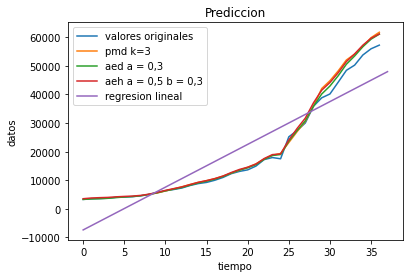

In [12]:
# Plot original data, PMS y AES
plt.plot(data, label='valores originales')
plt.plot(pmd5, label='pmd k=5')
plt.plot(aed3, label='aed a = 0,3')
plt.plot(aeh3, label='aeh a = 0,5 b = 0,3')
plt.plot(rl1, label='regresion lineal')
plt.xlabel('tiempo')
plt.ylabel('datos')
plt.title('Prediccion')
plt.legend()
plt.show()

In [24]:
def calcular_errores(data, pron):
    y_true = pd.Series(data)
    y_pred = pd.Series(pron)
    
    mask = (~y_true.isna()) & (~y_pred.isna())

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    #DAM
    dam= np.mean(np.abs((y_true_clean - y_pred_clean)))
    
    #EMC
    emc= np.mean(pow((y_true_clean - y_pred_clean),2))
    
    #PEMA
    pema = np.mean(np.abs((y_true_clean - y_pred_clean)/y_true_clean))*100
    
    #PME
    pme = np.mean((y_true_clean - y_pred_clean)/y_true_clean)*100
    
    return dam,emc,pema,pme


def mostrar_resultados(y_true,y_pred):
    dam,emc,pema,pme = calcular_errores(y_true,y_pred)
    print(f"DAM : {dam}")
    print(f"EMC : {emc}")
    print(f"PEMA: {pema}")
    print(f"PME: {pme}")
    


In [29]:
print("PREDICCION 1 : PMD K= 5")
mostrar_resultados(data,pmd5)

print("PREDICCION 2 : AED ALFA= 0.3")
mostrar_resultados(data,aed3)

PREDICCION 1 : PMD K= 5
DAM : 1364.1407142857147
EMC : 4248162.2985285735
PEMA: 6.105223327744955
PME: 4.452580351072431
PREDICCION 2 : AED ALFA= 0.3
DAM : 1108.404892139416
EMC : 3190629.544727722
PEMA: 6.354254019727788
PME: 5.679069937278237


In [49]:
print("PREDICCION 3 : aeh a= 0.5 y b 0.3")
mostrar_resultados(data,aeh3)

print("PREDICCION 4 : rl")
mostrar_resultados(data,rl1)

PREDICCION 3 : aeh a= 0.5 y b 0.3
DAM : 958.2195255285047
EMC : 2490216.2124916567
PEMA: 5.187050945763378
PME: 3.9197154599533666
PREDICCION 4 : rl
DAM : 5893.614317019723
EMC : 45050543.679283135
PEMA: 61.96563183399717
PME: 15.889695230678672
